# Task 3 — Dimensionality Reduction Techniques
**Course:** Machine Learning & Deep Learning  
**Points:** 10/60  
**School of Artificial Intelligence and Data Science**

---

## Overview
High-dimensional data is ubiquitous in machine learning. We study and apply:
1. **PCA** — Principal Component Analysis (linear)
2. **t-SNE** — t-distributed Stochastic Neighbor Embedding (non-linear)
3. **UMAP** — Uniform Manifold Approximation and Projection
4. **LDA** — Linear Discriminant Analysis (supervised)

## Step 0 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine, load_digits
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline

try:
    import umap
    UMAP_AVAILABLE = True
    print('UMAP available')
except ImportError:
    UMAP_AVAILABLE = False
    print('UMAP not installed. Install with: pip install umap-learn')
    print('Proceeding without UMAP...')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# Load datasets
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = wine.target
class_names = wine.target_names

digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# Standardize
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)
X_digits_scaled = scaler.fit_transform(X_digits)

print(f'Wine: {X_wine_scaled.shape}, Digits: {X_digits_scaled.shape}')

UMAP available
Wine: (178, 13), Digits: (1797, 64)


## Step 1 — PCA: Explained Variance Ratio (Scree Plot)

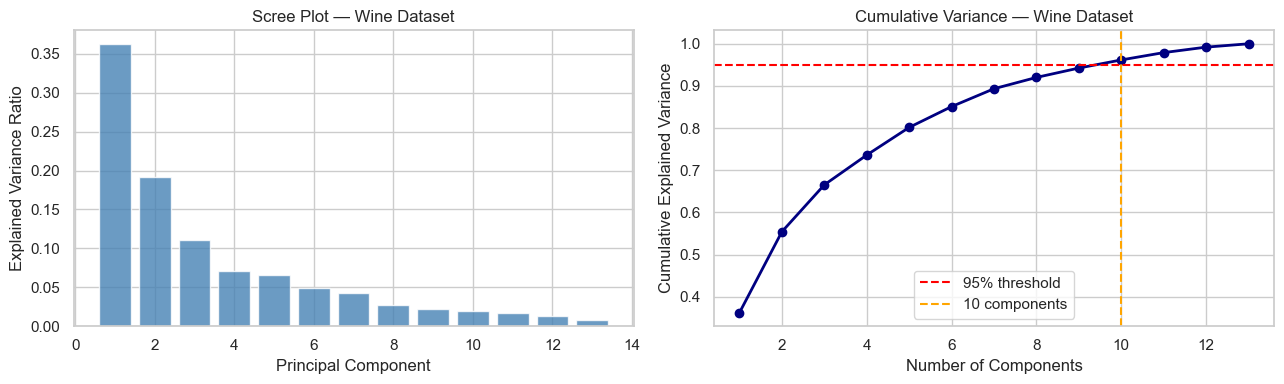

Components needed for 95% variance: 10


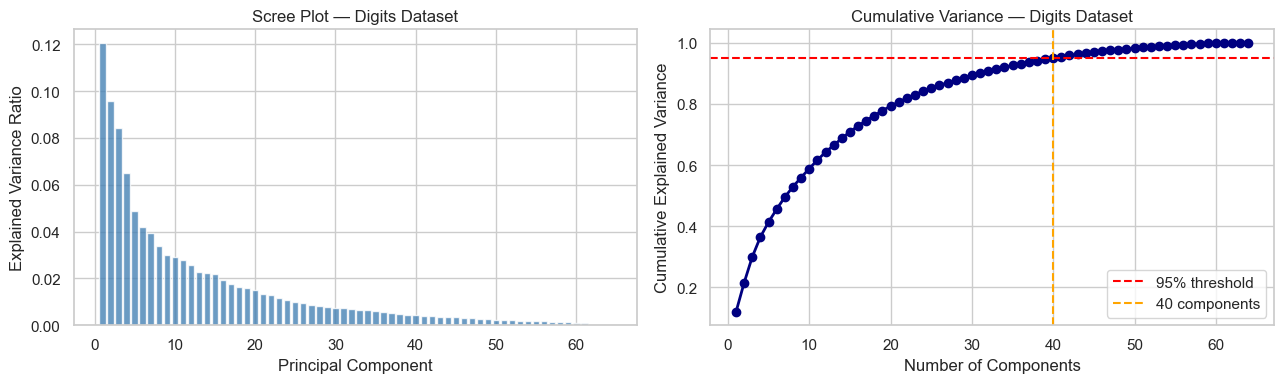

Components needed for 95% variance: 40


In [2]:
def plot_pca_variance(X, title):
    """Plot explained variance ratio and cumulative variance for PCA."""
    pca_full = PCA(random_state=RANDOM_STATE)
    pca_full.fit(X)
    
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    n_95 = np.argmax(cumvar >= 0.95) + 1
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    
    axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
                pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance Ratio')
    axes[0].set_title(f'Scree Plot — {title}')
    
    axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='navy', lw=2)
    axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
    axes[1].axvline(n_95, color='orange', linestyle='--', label=f'{n_95} components')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance')
    axes[1].set_title(f'Cumulative Variance — {title}')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'../results/T3_pca_variance_{title.split()[0]}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Components needed for 95% variance: {n_95}')
    return n_95

n95_wine   = plot_pca_variance(X_wine_scaled, 'Wine Dataset')
n95_digits = plot_pca_variance(X_digits_scaled, 'Digits Dataset')

## Step 2 — 2D Projections: PCA, t-SNE, UMAP, LDA

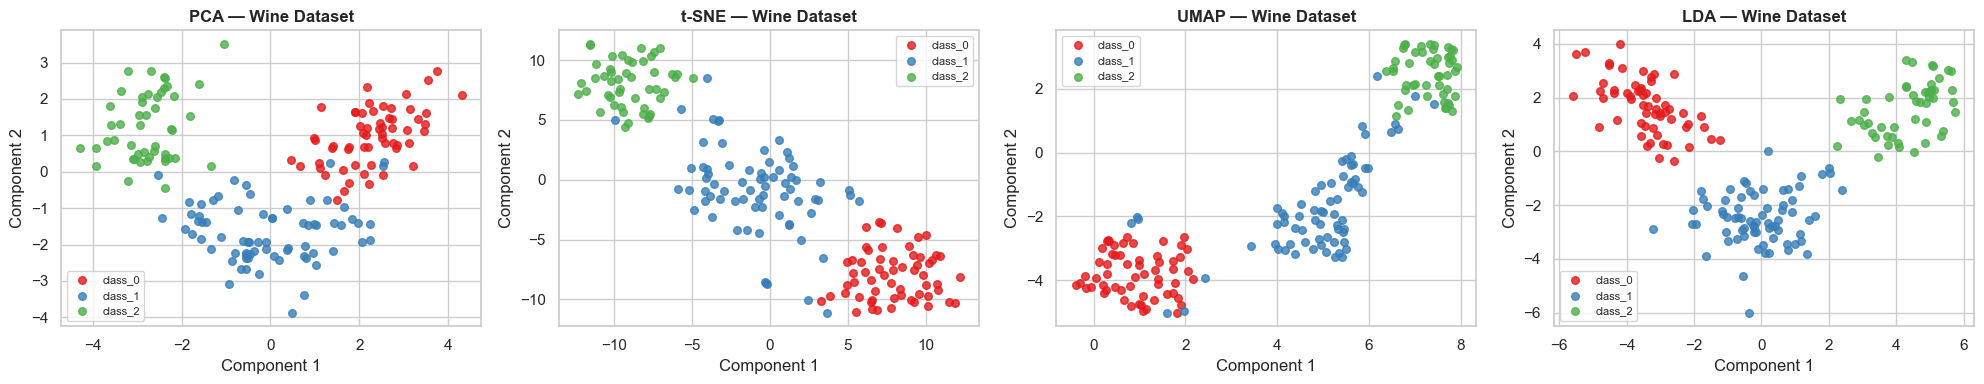

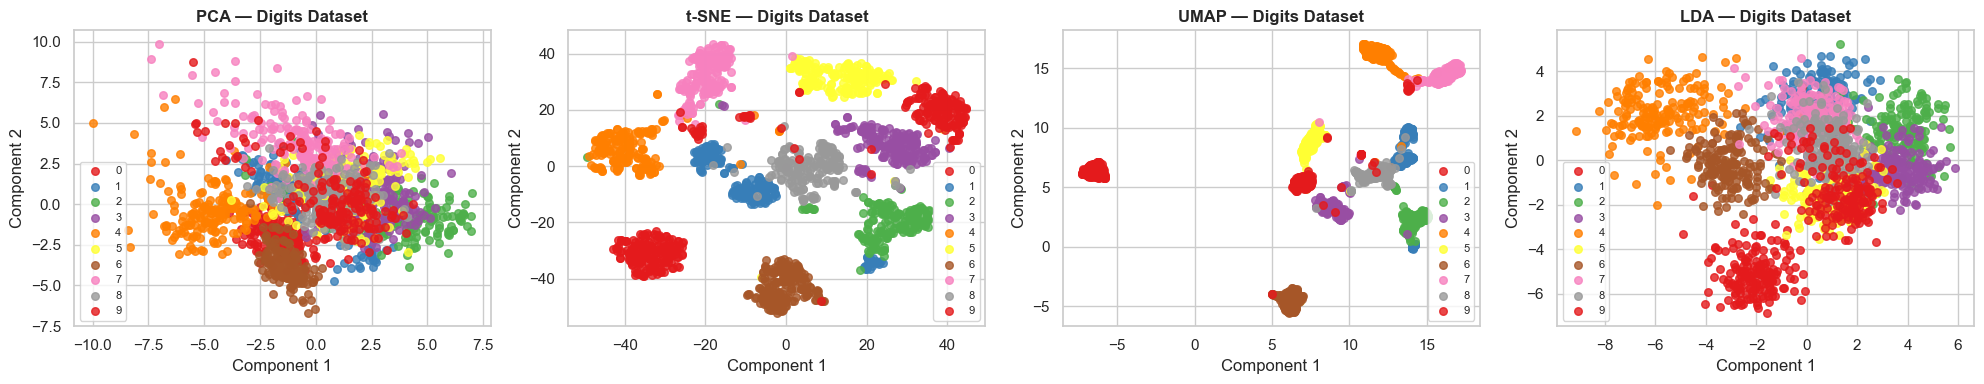

In [3]:
def visualize_all_reductions(X, y, class_names, dataset_name):
    """Apply PCA, t-SNE, UMAP, and LDA; plot 2D projections side by side."""
    
    reducers = {}
    reducers['PCA'] = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
    reducers['t-SNE'] = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
                             max_iter=1000).fit_transform(X)
    if UMAP_AVAILABLE:
        reducers['UMAP'] = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
    
    lda = LDA(n_components=min(2, len(np.unique(y))-1))
    lda_emb = lda.fit_transform(X, y)
    if lda_emb.shape[1] == 1:
        lda_emb = np.column_stack([lda_emb, np.zeros(len(lda_emb))])
    reducers['LDA'] = lda_emb
    
    n_plots = len(reducers)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    palette = sns.color_palette('Set1', n_colors=len(np.unique(y)))
    
    for ax, (name, embedding) in zip(axes, reducers.items()):
        for cls_idx, cls_name in enumerate(class_names):
            mask = y == cls_idx
            ax.scatter(embedding[mask, 0], embedding[mask, 1],
                       c=[palette[cls_idx]], label=cls_name, s=30, alpha=0.8)
        ax.set_title(f'{name} — {dataset_name}', fontweight='bold')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.legend(fontsize=8, loc='best')
    
    plt.tight_layout()
    plt.savefig(f'../results/T3_reductions_{dataset_name.split()[0]}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_all_reductions(X_wine_scaled, y_wine, class_names, 'Wine Dataset')
visualize_all_reductions(X_digits_scaled, y_digits, [str(i) for i in range(10)], 'Digits Dataset')

## Step 3 — Classifier Performance: Full vs PCA-Reduced


=== Wine Dataset — Full vs PCA (10 components) ===
  Full features -> Test Acc: 1.0000  CV Acc: 0.9721
  PCA 10 comps -> Test Acc: 0.9259  CV Acc: 0.9719
  Dimension reduction: 13 -> 10 (76.9%)


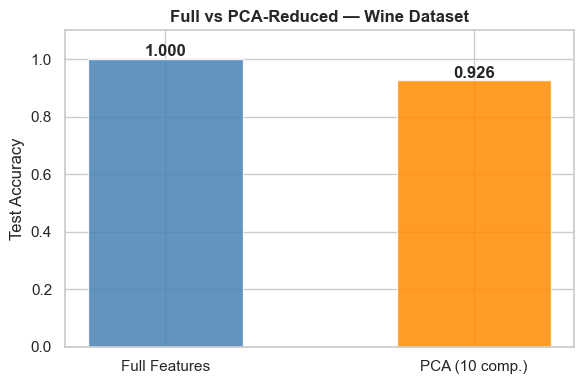


=== Digits Dataset — Full vs PCA (40 components) ===
  Full features -> Test Acc: 0.9685  CV Acc: 0.9394
  PCA 40 comps -> Test Acc: 0.9481  CV Acc: 0.9160
  Dimension reduction: 64 -> 40 (62.5%)


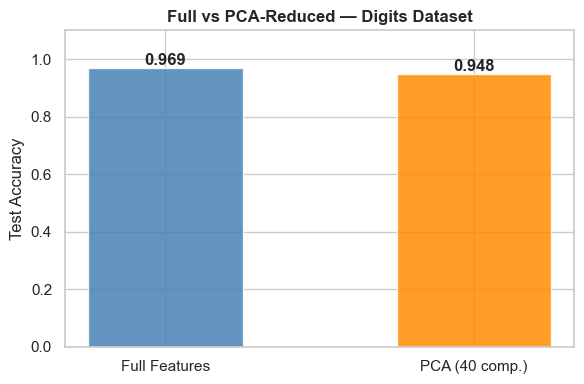

In [4]:
def compare_full_vs_pca(X, y, n_components_95, dataset_name):
    """Train RandomForest on full features vs PCA-reduced."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
    
    clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
    
    clf.fit(X_train, y_train)
    acc_full = clf.score(X_test, y_test)
    cv_full = cross_val_score(clf, X, y, cv=5).mean()
    
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    clf.fit(X_train_pca, y_train)
    acc_pca = clf.score(X_test_pca, y_test)
    X_pca = pca.fit_transform(X)
    cv_pca = cross_val_score(clf, X_pca, y, cv=5).mean()
    
    print(f'\n=== {dataset_name} — Full vs PCA ({n_components_95} components) ===')
    print(f'  Full features -> Test Acc: {acc_full:.4f}  CV Acc: {cv_full:.4f}')
    print(f'  PCA {n_components_95} comps -> Test Acc: {acc_pca:.4f}  CV Acc: {cv_pca:.4f}')
    print(f'  Dimension reduction: {X.shape[1]} -> {n_components_95} ({100*n_components_95/X.shape[1]:.1f}%)')
    
    fig, ax = plt.subplots(figsize=(6, 4))
    labels = ['Full Features', f'PCA ({n_components_95} comp.)']
    accs = [acc_full, acc_pca]
    bars = ax.bar(labels, accs, color=['steelblue','darkorange'], alpha=0.85, width=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Test Accuracy')
    ax.set_title(f'Full vs PCA-Reduced — {dataset_name}', fontweight='bold')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01, f'{acc:.3f}', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

compare_full_vs_pca(X_wine_scaled, y_wine, n95_wine, 'Wine Dataset')
compare_full_vs_pca(X_digits_scaled, y_digits, n95_digits, 'Digits Dataset')

## Step 4 — Analysis & Discussion

**PCA** is unsupervised and preserves maximum variance. Good for preprocessing before SVM or Logistic Regression.

**t-SNE** provides excellent visualization quality but is non-deterministic and computationally expensive. Cannot transform new samples.

**UMAP** combines visualization quality with the ability to transform new data (supports `transform()`).

**LDA** maximizes between-class variance relative to within-class variance. Best for supervised dimensionality reduction when class labels are available.

Key insight: Dimensionality reduction is about understanding the intrinsic structure of data, not just compression.